# Week 2 Assignment — Describe Your Data

**Aashish Chand**  
International American University  
AIM 402 Statistics for Data Analysis Using Python  
Professor Poshan Karki  
September 28, 2026

---

**Dataset:** IBM Telco Customer Churn (BlastChar, n = 7,043 customers)  
**Numerical variables:** `tenure` (months as a customer) and `MonthlyCharges` (US dollars)  
**Categorical variable for comparison:** `Contract` (Month-to-month / One year / Two year)

All 7,043 rows are kept. `tenure` and `MonthlyCharges` have no missing values, so the 11 customers with blank `TotalCharges` (all `tenure` = 0) stay in this analysis.


In [1]:
# Cell 1 — Load libraries and the full dataset (n = 7,043)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

df = pd.read_csv("Telco-Customer-Churn.csv")

# Convert TotalCharges for inspection only. Do not drop rows: tenure and
# MonthlyCharges are complete, and the 11 blanks are the tenure = 0 customers.
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"].astype(str).str.strip(), errors="coerce"
)

VAR1 = "tenure"
VAR2 = "MonthlyCharges"
x1 = df[VAR1]
x2 = df[VAR2]

print("Dataset shape:", df.shape)
print(f"Missing in {VAR1}: {x1.isna().sum()}")
print(f"Missing in {VAR2}: {x2.isna().sum()}")
print(f"Blank TotalCharges (kept): {df['TotalCharges'].isna().sum()}")
print(f"tenure == 0 rows (kept): {(df['tenure'] == 0).sum()}")
df[[VAR1, VAR2, "Contract", "InternetService", "Churn"]].head(10)


Dataset shape: (7043, 21)
Missing in tenure: 0
Missing in MonthlyCharges: 0
Blank TotalCharges (kept): 11
tenure == 0 rows (kept): 11


,tenure,MonthlyCharges,Contract,InternetService,Churn
0,1,29.85,Month-to-month,DSL,No
1,34,56.95,One year,DSL,No
2,2,53.85,Month-to-month,DSL,Yes
3,45,42.30,One year,DSL,No
4,2,70.70,Month-to-month,Fiber optic,Yes
5,8,99.65,Month-to-month,Fiber optic,Yes
6,22,89.10,Month-to-month,Fiber optic,No
7,10,29.75,Month-to-month,DSL,No
8,28,104.80,Month-to-month,Fiber optic,Yes
9,62,56.15,One year,DSL,No


In [2]:
# Cell 2 — Summary table for the two analysis variables
def describe_one(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    return {
        "n": int(series.count()),
        "mean": series.mean(),
        "median": series.median(),
        "std (n-1)": series.std(),
        "Q1": q1,
        "Q3": q3,
        "IQR": q3 - q1,
        "min": series.min(),
        "max": series.max(),
        "skew": series.skew(),
    }

summary = pd.DataFrame({VAR1: describe_one(x1), VAR2: describe_one(x2)})
print("All later cells use this same df (n = {}).".format(len(df)))
summary.round(3)


All later cells use this same df (n = 7043).


,tenure,MonthlyCharges
n,7043.000,7043.000
mean,32.371,64.762
median,29.000,70.350
std (n-1),24.559,30.090
Q1,9.000,35.500
Q3,55.000,89.850
IQR,46.000,54.350
min,0.000,18.250
max,72.000,118.750
skew,0.240,-0.221


---
## 2. Centre, Shape and Spread
---


In [3]:
# Cell 3 — Summary statistics for tenure
mean_t = x1.mean()
median_t = x1.median()
std_t = x1.std()
q1_t = x1.quantile(0.25)
q3_t = x1.quantile(0.75)
iqr_t = q3_t - q1_t
min_t = x1.min()
max_t = x1.max()
skew_t = x1.skew()
gap_t = mean_t - median_t

print("=== tenure ===")
print(f"  n      = {x1.count()}")
print(f"  Mean   = {mean_t:.2f}")
print(f"  Median = {median_t:.2f}")
print(f"  SD     = {std_t:.2f}")
print(f"  Q1     = {q1_t:.2f}")
print(f"  Q3     = {q3_t:.2f}")
print(f"  IQR    = {iqr_t:.2f}")
print(f"  Min    = {min_t},  Max = {max_t}")
print(f"  Skew   = {skew_t:.4f}")


=== tenure ===
  n      = 7043
  Mean   = 32.37
  Median = 29.00
  SD     = 24.56
  Q1     = 9.00
  Q3     = 55.00
  IQR    = 46.00
  Min    = 0,  Max = 72
  Skew   = 0.2395


In [4]:
# Cell 4 — Summary statistics for MonthlyCharges
mean_mc = x2.mean()
median_mc = x2.median()
std_mc = x2.std()
q1_mc = x2.quantile(0.25)
q3_mc = x2.quantile(0.75)
iqr_mc = q3_mc - q1_mc
min_mc = x2.min()
max_mc = x2.max()
skew_mc = x2.skew()
gap_mc = mean_mc - median_mc

print("=== MonthlyCharges ===")
print(f"  n      = {x2.count()}")
print(f"  Mean   = {mean_mc:.2f}")
print(f"  Median = {median_mc:.2f}")
print(f"  SD     = {std_mc:.2f}")
print(f"  Q1     = {q1_mc:.2f}")
print(f"  Q3     = {q3_mc:.2f}")
print(f"  IQR    = {iqr_mc:.2f}")
print(f"  Min    = {min_mc},  Max = {max_mc}")
print(f"  Skew   = {skew_mc:.4f}")


=== MonthlyCharges ===
  n      = 7043
  Mean   = 64.76
  Median = 70.35
  SD     = 30.09
  Q1     = 35.50
  Q3     = 89.85
  IQR    = 54.35
  Min    = 18.25,  Max = 118.75
  Skew   = -0.2205


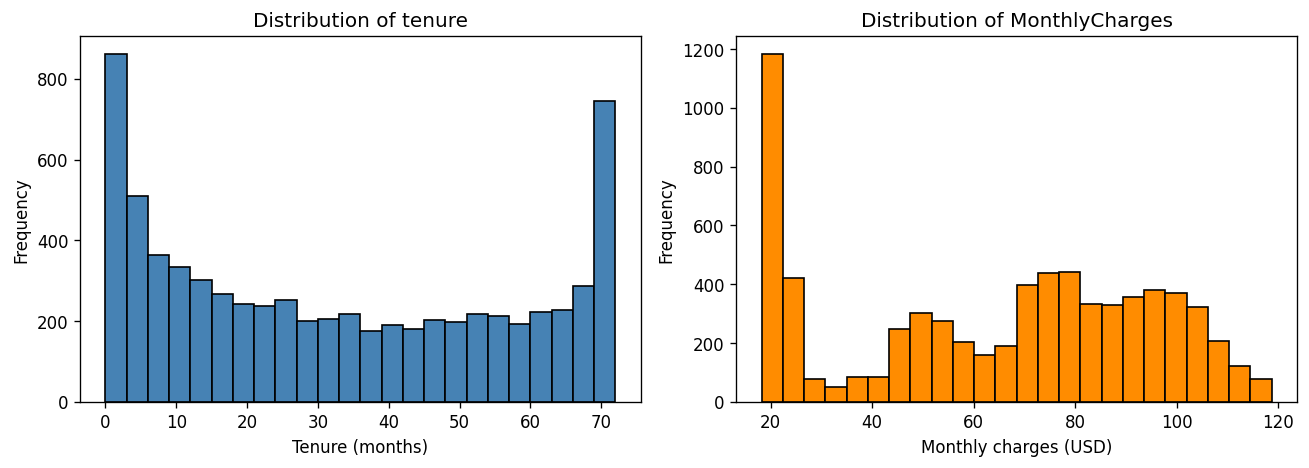

In [5]:
# Cell 5 — Histograms used for the shape descriptions
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(x1, bins=24, color="steelblue", edgecolor="black")
axes[0].set_title("Distribution of tenure")
axes[0].set_xlabel("Tenure (months)")
axes[0].set_ylabel("Frequency")
axes[1].hist(x2, bins=24, color="darkorange", edgecolor="black")
axes[1].set_title("Distribution of MonthlyCharges")
axes[1].set_xlabel("Monthly charges (USD)")
axes[1].set_ylabel("Frequency")
plt.tight_layout()
plt.show()


In [6]:
# Cell 6 — Describe centre, shape, spread from the statistics just computed
print("=== tenure: Centre, Shape, Spread ===")
print(
    f"  Centre : The centre is {median_t:.0f} months (median), "
    f"with a mean of {mean_t:.2f} months."
)
print(
    "  Shape  : Mildly right-skewed, with a spike of new customers at 0–1 months"
)
print("           and a second spike at the 72-month ceiling.")
print(
    f"  Spread : Wide, with SD = {std_t:.2f} months and IQR = {iqr_t:.0f} months, "
    f"values from {min_t:.0f} to {max_t:.0f}."
)
print()
print("=== MonthlyCharges: Centre, Shape, Spread ===")
print(
    f"  Centre : The centre is about ${median_mc:.2f} (median), "
    f"with a mean of ${mean_mc:.2f}."
)
print(
    "  Shape  : Mildly left-skewed and bimodal — a tall peak near $20 and a"
)
print("           broad hump between roughly $70 and $100.")
print(
    f"  Spread : Wide, with SD = ${std_mc:.2f} and IQR = ${iqr_mc:.2f}, "
    f"from ${min_mc:.2f} to ${max_mc:.2f}."
)


=== tenure: Centre, Shape, Spread ===
  Centre : The centre is 29 months (median), with a mean of 32.37 months.
  Shape  : Mildly right-skewed, with a spike of new customers at 0–1 months
           and a second spike at the 72-month ceiling.
  Spread : Wide, with SD = 24.56 months and IQR = 46 months, values from 0 to 72.

=== MonthlyCharges: Centre, Shape, Spread ===
  Centre : The centre is about $70.35 (median), with a mean of $64.76.
  Shape  : Mildly left-skewed and bimodal — a tall peak near $20 and a
           broad hump between roughly $70 and $100.
  Spread : Wide, with SD = $30.09 and IQR = $54.35, from $18.25 to $118.75.


In [7]:
# Cell 7 — Skewness with .skew() checked against the mean–median gap
print("=== Skewness Check ===")
print()
print("tenure:")
print(f"  .skew()       = {skew_t:.4f}")
print(f"  Mean - Median = {mean_t:.2f} - {median_t:.2f} = {gap_t:.4f}")
if skew_t > 0 and gap_t > 0:
    print("  Both positive — they agree on mild right skew.")
elif skew_t < 0 and gap_t < 0:
    print("  Both negative — they agree on mild left skew.")
else:
    print("  Signs DISAGREE — investigate further.")

print()
print("MonthlyCharges:")
print(f"  .skew()       = {skew_mc:.4f}")
print(f"  Mean - Median = {mean_mc:.2f} - {median_mc:.2f} = {gap_mc:.4f}")
if skew_mc > 0 and gap_mc > 0:
    print("  Both positive — they agree on mild right skew.")
elif skew_mc < 0 and gap_mc < 0:
    print("  Both negative — they agree on mild left skew.")
else:
    print("  Signs DISAGREE — investigate further.")

print()
print("Neither pair disagrees, so nothing extra needed investigating for sign.")
print("Both skews are small. The histograms show the mean–median rule is")
print("only a rough guide here: MonthlyCharges has two peaks, which a")
print("single skew value cannot capture.")


=== Skewness Check ===

tenure:
  .skew()       = 0.2395
  Mean - Median = 32.37 - 29.00 = 3.3711
  Both positive — they agree on mild right skew.

MonthlyCharges:
  .skew()       = -0.2205
  Mean - Median = 64.76 - 70.35 = -5.5883
  Both negative — they agree on mild left skew.

Neither pair disagrees, so nothing extra needed investigating for sign.
Both skews are small. The histograms show the mean–median rule is
only a rough guide here: MonthlyCharges has two peaks, which a
single skew value cannot capture.


---
## 3. Verifying the Standard Deviation by Hand
---


In [8]:
# Cell 8 — Manual standard deviation: tenure (first 10 rows)
subset_t = x1.head(10)
n = len(subset_t)
subset_mean_t = subset_t.sum() / n

print("=== Manual SD verification: tenure (first 10 rows) ===")
print(f"Values: {[int(v) for v in subset_t]}")
print(f"Step 1 — Mean = {subset_t.sum():.2f} / {n} = {subset_mean_t:.2f}")
print()
print("Step 2 — Squared deviations:")
print(f"{'i':<4} {'x':<8} {'x - mean':<12} {'(x - mean)^2':<14}")
sum_sq_t = 0
for i, val in enumerate(subset_t, start=1):
    dev = val - subset_mean_t
    sq_dev = dev ** 2
    sum_sq_t = sum_sq_t + sq_dev
    print(f"{i:<4} {val:<8} {dev:<12.2f} {sq_dev:<14.4f}")

print()
print(f"Step 3 — Sum of squared deviations = {sum_sq_t:.4f}")
variance_t = sum_sq_t / (n - 1)
print(f"Step 4 — Sample variance = {sum_sq_t:.4f} / {n - 1} = {variance_t:.4f}")
manual_std_t = variance_t ** 0.5
print(f"Step 5 — Manual SD = sqrt({variance_t:.4f}) = {manual_std_t:.4f}")
print()
pandas_std_t = subset_t.std()
print(f"pandas .std() = {pandas_std_t:.4f}")
print(f"Manual  std   = {manual_std_t:.4f}")
print(f"Match: {np.isclose(manual_std_t, pandas_std_t)}")


=== Manual SD verification: tenure (first 10 rows) ===
Values: [1, 34, 2, 45, 2, 8, 22, 10, 28, 62]
Step 1 — Mean = 214.00 / 10 = 21.40

Step 2 — Squared deviations:
i    x        x - mean     (x - mean)^2  
1    1        -20.40       416.1600      
2    34       12.60        158.7600      
3    2        -19.40       376.3600      
4    45       23.60        556.9600      
5    2        -19.40       376.3600      
6    8        -13.40       179.5600      
7    22       0.60         0.3600        
8    10       -11.40       129.9600      
9    28       6.60         43.5600       
10   62       40.60        1648.3600     

Step 3 — Sum of squared deviations = 3886.4000
Step 4 — Sample variance = 3886.4000 / 9 = 431.8222
Step 5 — Manual SD = sqrt(431.8222) = 20.7803

pandas .std() = 20.7803
Manual  std   = 20.7803
Match: True


In [9]:
# Cell 9 — Manual standard deviation: MonthlyCharges (first 10 rows)
subset_mc = x2.head(10)
n_mc = len(subset_mc)
subset_mean_mc = subset_mc.sum() / n_mc

print("=== Manual SD verification: MonthlyCharges (first 10 rows) ===")
print(f"Values: {[float(v) for v in subset_mc]}")
print(f"Step 1 — Mean = {subset_mc.sum():.2f} / {n_mc} = {subset_mean_mc:.4f}")
print()
print("Step 2 — Squared deviations:")
print(f"{'i':<4} {'x':<10} {'x - mean':<12} {'(x - mean)^2':<14}")
sum_sq_mc = 0
for i, val in enumerate(subset_mc, start=1):
    dev = val - subset_mean_mc
    sq_dev = dev ** 2
    sum_sq_mc = sum_sq_mc + sq_dev
    print(f"{i:<4} {val:<10.2f} {dev:<12.2f} {sq_dev:<14.4f}")

print()
print(f"Step 3 — Sum of squared deviations = {sum_sq_mc:.4f}")
variance_mc = sum_sq_mc / (n_mc - 1)
print(f"Step 4 — Sample variance = {sum_sq_mc:.4f} / {n_mc - 1} = {variance_mc:.4f}")
manual_std_mc = variance_mc ** 0.5
print(f"Step 5 — Manual SD = sqrt({variance_mc:.4f}) = {manual_std_mc:.4f}")
print()
pandas_std_mc = subset_mc.std()
print(f"pandas .std() = {pandas_std_mc:.4f}")
print(f"Manual  std   = {manual_std_mc:.4f}")
print(f"Match: {np.isclose(manual_std_mc, pandas_std_mc)}")
print()
print("The match confirms that .std() is a sample standard deviation,")
print("dividing by n − 1 and not by n.")


=== Manual SD verification: MonthlyCharges (first 10 rows) ===
Values: [29.85, 56.95, 53.85, 42.3, 70.7, 99.65, 89.1, 29.75, 104.8, 56.15]
Step 1 — Mean = 633.10 / 10 = 63.3100

Step 2 — Squared deviations:
i    x          x - mean     (x - mean)^2  
1    29.85      -33.46       1119.5716     
2    56.95      -6.36        40.4496       
3    53.85      -9.46        89.4916       
4    42.30      -21.01       441.4201      
5    70.70      7.39         54.6121       
6    99.65      36.34        1320.5956     
7    89.10      25.79        665.1241      
8    29.75      -33.56       1126.2736     
9    104.80     41.49        1721.4201     
10   56.15      -7.16        51.2656       

Step 3 — Sum of squared deviations = 6630.2240
Step 4 — Sample variance = 6630.2240 / 9 = 736.6916
Step 5 — Manual SD = sqrt(736.6916) = 27.1421

pandas .std() = 27.1421
Manual  std   = 27.1421
Match: True

The match confirms that .std() is a sample standard deviation,
dividing by n − 1 and not by n.


---
## 4. Histogram Bin Widths
---



Bin width choice:
  I would report the $5 bin width (21 bins).
  At $2 the histogram is jagged — counts bounce from bar to bar, so some shape is noise.
  At $10 there are only 11 bars, and the sharp low-charge peak is
  blended into a single first bar of 1606 customers, hiding that it
  sits right at the minimum of $18.25.
  $5 keeps the clear peak at the low end and the broad hump from $70 to $100 without noise.
  The choice matters because bin width controls what the reader sees — the same data can
  look smooth, jagged or unimodal depending on it (Bruce et al., 2020).


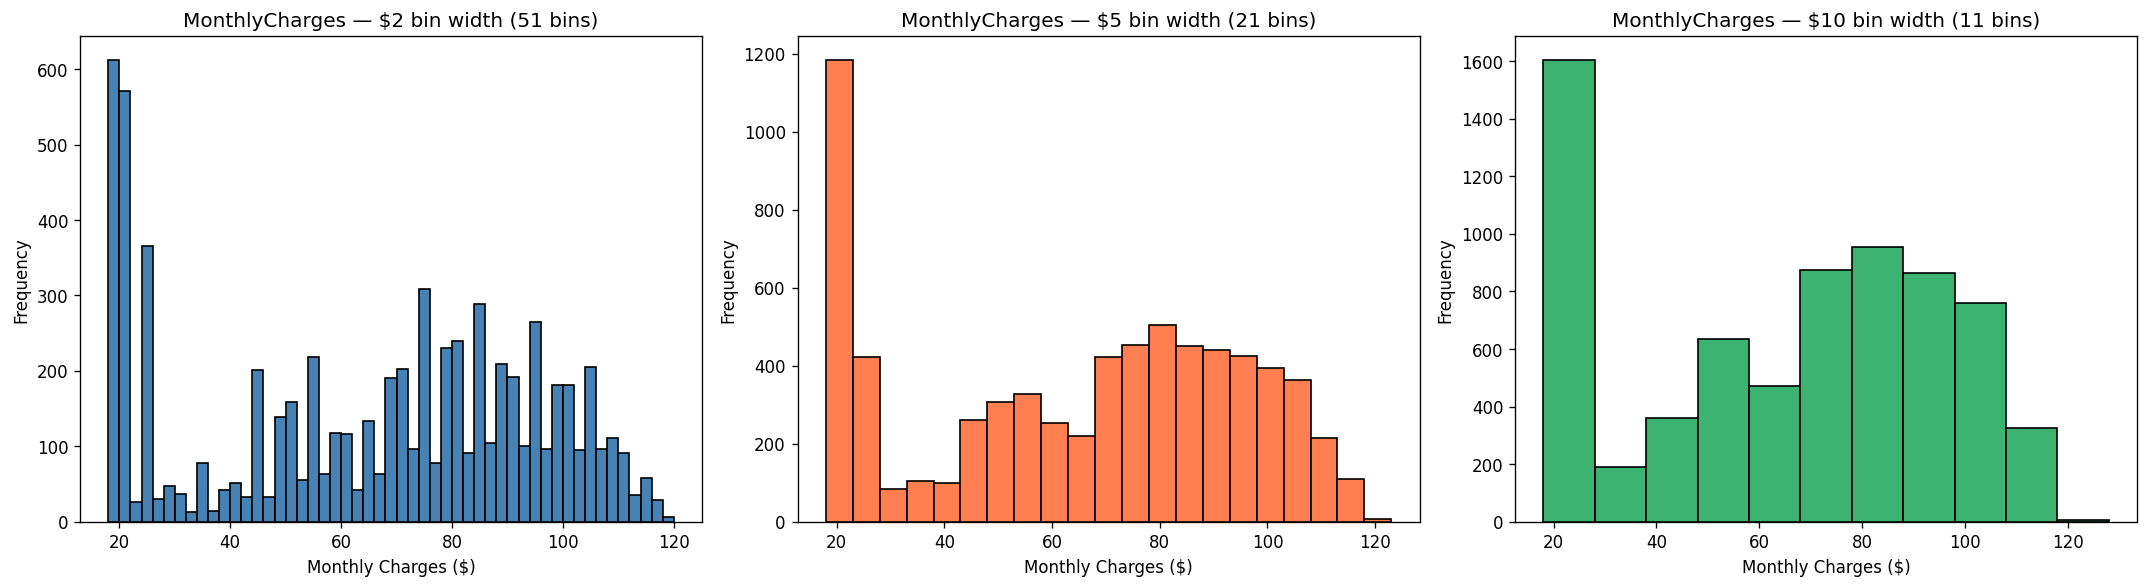

In [10]:
# Cell 10 — Histogram of MonthlyCharges at three bin widths ($2, $5, $10)
min_val = x2.min()
max_val = x2.max()
bins_2 = np.arange(np.floor(min_val), max_val + 2, 2)
bins_5 = np.arange(np.floor(min_val), max_val + 5, 5)
bins_10 = np.arange(np.floor(min_val), max_val + 10, 10)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].hist(x2, bins=bins_2, color="steelblue", edgecolor="black")
axes[0].set_title(f"MonthlyCharges — $2 bin width ({len(bins_2) - 1} bins)")
axes[0].set_xlabel("Monthly Charges ($)")
axes[0].set_ylabel("Frequency")

axes[1].hist(x2, bins=bins_5, color="coral", edgecolor="black")
axes[1].set_title(f"MonthlyCharges — $5 bin width ({len(bins_5) - 1} bins)")
axes[1].set_xlabel("Monthly Charges ($)")
axes[1].set_ylabel("Frequency")

axes[2].hist(x2, bins=bins_10, color="mediumseagreen", edgecolor="black")
axes[2].set_title(f"MonthlyCharges — $10 bin width ({len(bins_10) - 1} bins)")
axes[2].set_xlabel("Monthly Charges ($)")
axes[2].set_ylabel("Frequency")
plt.tight_layout()
plt.show()

counts_10, _ = np.histogram(x2, bins=bins_10)
print()
print("Bin width choice:")
print(f"  I would report the $5 bin width ({len(bins_5) - 1} bins).")
print("  At $2 the histogram is jagged — counts bounce from bar to bar, so some shape is noise.")
print(
    f"  At $10 there are only {len(bins_10) - 1} bars, and the sharp low-charge peak is"
)
print(
    f"  blended into a single first bar of {counts_10[0]} customers, hiding that it"
)
print(f"  sits right at the minimum of ${min_val:.2f}.")
print("  $5 keeps the clear peak at the low end and the broad hump from $70 to $100 without noise.")
print("  The choice matters because bin width controls what the reader sees — the same data can")
print("  look smooth, jagged or unimodal depending on it (Bruce et al., 2020).")


In [11]:
# Cell 11 — Why the low peak exists: customers with no internet service
no_internet = df[df["InternetService"] == "No"]
print(f"Customers with no internet service: {len(no_internet)}")
print(
    f"Their MonthlyCharges range: ${no_internet['MonthlyCharges'].min():.2f} "
    f"to ${no_internet['MonthlyCharges'].max():.2f}"
)
print("This explains the low peak in the histogram: phone-only plans cluster near $20.")


Customers with no internet service: 1526
Their MonthlyCharges range: $18.25 to $26.90
This explains the low peak in the histogram: phone-only plans cluster near $20.


---
## 5. Boxplots, 1.5 × IQR Fences and Outliers
---


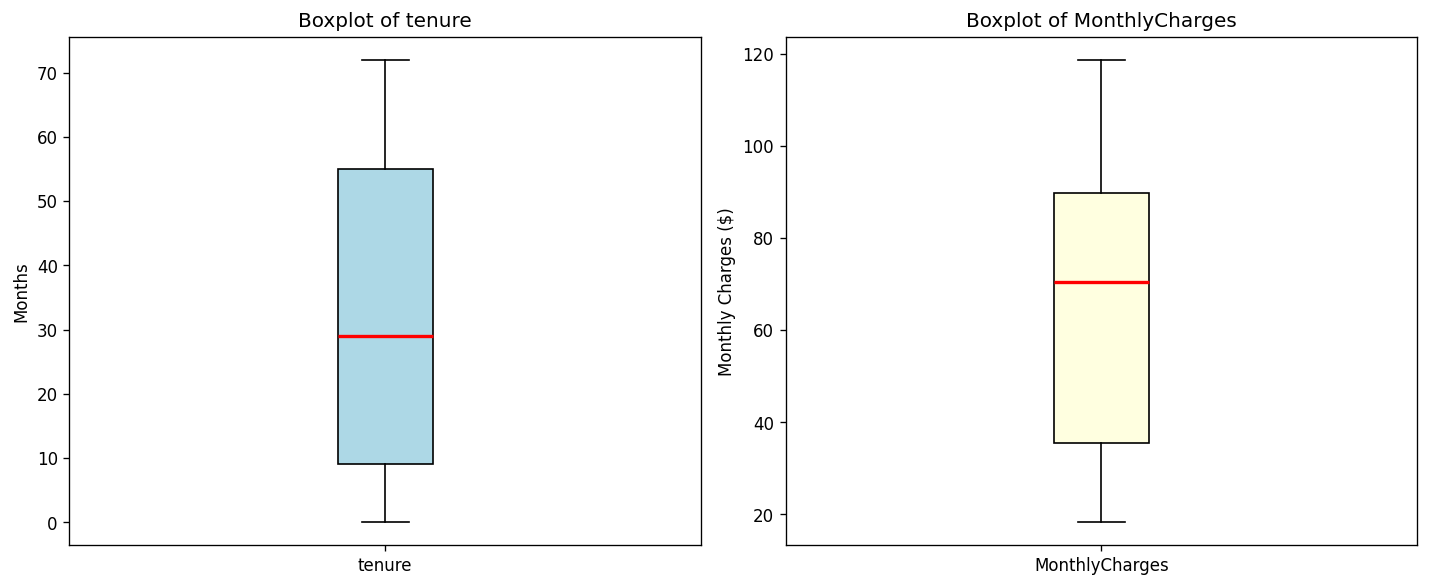

In [12]:
# Cell 12 — Boxplots of tenure and MonthlyCharges
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].boxplot(
    x1,
    vert=True,
    patch_artist=True,
    tick_labels=["tenure"],
    boxprops=dict(facecolor="lightblue"),
    medianprops=dict(color="red", linewidth=2),
)
axes[0].set_title("Boxplot of tenure")
axes[0].set_ylabel("Months")

axes[1].boxplot(
    x2,
    vert=True,
    patch_artist=True,
    tick_labels=["MonthlyCharges"],
    boxprops=dict(facecolor="lightyellow"),
    medianprops=dict(color="red", linewidth=2),
)
axes[1].set_title("Boxplot of MonthlyCharges")
axes[1].set_ylabel("Monthly Charges ($)")
plt.tight_layout()
plt.show()


In [13]:
# Cell 13 — 1.5 × IQR fences and outlier rows
lower_fence_t = q1_t - 1.5 * iqr_t
upper_fence_t = q3_t + 1.5 * iqr_t
outliers_t = df[(x1 < lower_fence_t) | (x1 > upper_fence_t)]

print("=== 1.5 × IQR Fences: tenure ===")
print(f"  Q1 = {q1_t}, Q3 = {q3_t}, IQR = {iqr_t}")
print(f"  Lower Fence = {q1_t} - 1.5×{iqr_t} = {lower_fence_t:.2f}")
print(f"  Upper Fence = {q3_t} + 1.5×{iqr_t} = {upper_fence_t:.2f}")
print(f"  Outliers: {len(outliers_t)} rows")
print()

lower_fence_mc = q1_mc - 1.5 * iqr_mc
upper_fence_mc = q3_mc + 1.5 * iqr_mc
outliers_mc = df[(x2 < lower_fence_mc) | (x2 > upper_fence_mc)]

print("=== 1.5 × IQR Fences: MonthlyCharges ===")
print(f"  Q1 = {q1_mc:.2f}, Q3 = {q3_mc:.2f}, IQR = {iqr_mc:.2f}")
print(f"  Lower Fence = {q1_mc:.2f} - 1.5×{iqr_mc:.2f} = {lower_fence_mc:.2f}")
print(f"  Upper Fence = {q3_mc:.2f} + 1.5×{iqr_mc:.2f} = {upper_fence_mc:.2f}")
print(f"  Outliers: {len(outliers_mc)} rows")
print()
print("All values for both variables lie inside the fences, so the rule flags zero rows.")
print("This is unsurprising: both variables are bounded (tenure by 0 and 72, charges")
print("by the plan prices) and have wide IQRs.")


=== 1.5 × IQR Fences: tenure ===
  Q1 = 9.0, Q3 = 55.0, IQR = 46.0
  Lower Fence = 9.0 - 1.5×46.0 = -60.00
  Upper Fence = 55.0 + 1.5×46.0 = 124.00
  Outliers: 0 rows

=== 1.5 × IQR Fences: MonthlyCharges ===
  Q1 = 35.50, Q3 = 89.85, IQR = 54.35
  Lower Fence = 35.50 - 1.5×54.35 = -46.02
  Upper Fence = 89.85 + 1.5×54.35 = 171.38
  Outliers: 0 rows

All values for both variables lie inside the fences, so the rule flags zero rows.
This is unsurprising: both variables are bounded (tenure by 0 and 72, charges
by the plan prices) and have wide IQRs.


In [14]:
# Cell 14 — Extreme values, since the IQR rule found nothing
tenure_zero = df[df["tenure"] == 0]
print(f"(a) Tenure = 0 rows: {len(tenure_zero)}")
print(tenure_zero[["customerID", "tenure", "TotalCharges", "Contract", "Churn"]].to_string(index=False))
print("    These have blank TotalCharges (NaN after conversion).")
print("    That is consistent with customers who just signed up and had not yet been billed.")
print("    Judgment: LEGITIMATE OBSERVATION, not a recording error.")
print()

tenure_72 = df[df["tenure"] == 72]
print(f"(b) Tenure = 72 rows: {len(tenure_72)}")
print(f"    Most common contract type: {tenure_72['Contract'].value_counts().idxmax()}")
print("    Looks like the edge of the observation window — legitimate,")
print("    but 72 is a ceiling, not the true length of every long relationship.")
print()

max_mc = x2.max()
max_mc_row = df[df["MonthlyCharges"] == max_mc]
print(f"(c) Maximum MonthlyCharges = ${max_mc:.2f}")
print(max_mc_row[["customerID", "MonthlyCharges", "InternetService", "Contract"]].to_string(index=False))
print("    Fibre-optic customer on a two-year contract — plausible for a fully bundled plan.")
print("    Judgment: LEGITIMATE EXTREME OBSERVATION.")
print()
print("Whether a charge reflects a billing error cannot be determined without")
print("the billing records, but nothing in the other fields contradicts these values.")


(a) Tenure = 0 rows: 11
customerID  tenure  TotalCharges Contract Churn
4472-LVYGI       0           NaN Two year    No
3115-CZMZD       0           NaN Two year    No
5709-LVOEQ       0           NaN Two year    No
4367-NUYAO       0           NaN Two year    No
1371-DWPAZ       0           NaN Two year    No
7644-OMVMY       0           NaN Two year    No
3213-VVOLG       0           NaN Two year    No
2520-SGTTA       0           NaN Two year    No
2923-ARZLG       0           NaN One year    No
4075-WKNIU       0           NaN Two year    No
2775-SEFEE       0           NaN Two year    No
    These have blank TotalCharges (NaN after conversion).
    That is consistent with customers who just signed up and had not yet been billed.
    Judgment: LEGITIMATE OBSERVATION, not a recording error.

(b) Tenure = 72 rows: 362
    Most common contract type: Two year
    Looks like the edge of the observation window — legitimate,
    but 72 is a ceiling, not the true length of every long relat

---
## 6. Z-Scores and the Empirical Rule
---


In [15]:
# Cell 15 — Z-scores for tenure (using tenure's own mean and sample SD)
z_tenure = (x1 - mean_t) / std_t
total = len(z_tenure)
pct_1sd_t = (z_tenure.abs() <= 1).mean() * 100
pct_2sd_t = (z_tenure.abs() <= 2).mean() * 100
pct_3sd_t = (z_tenure.abs() <= 3).mean() * 100
within_1sd_t = int((z_tenure.abs() <= 1).sum())
within_2sd_t = int((z_tenure.abs() <= 2).sum())
within_3sd_t = int((z_tenure.abs() <= 3).sum())

print("=== Z-Score Analysis: tenure ===")
print(f"  Within ±1 SD: {within_1sd_t}/{total} = {pct_1sd_t:.2f}%  (Normal: 68%)")
print(f"  Within ±2 SD: {within_2sd_t}/{total} = {pct_2sd_t:.2f}%  (Normal: 95%)")
print(f"  Within ±3 SD: {within_3sd_t}/{total} = {pct_3sd_t:.2f}%  (Normal: 99.7%)")
print(f"  Min z        = {z_tenure.min():.2f}")
print(f"  Max z        = {z_tenure.max():.2f}")
print(f"  Max |z|      = {z_tenure.abs().max():.2f}")


=== Z-Score Analysis: tenure ===
  Within ±1 SD: 3756/7043 = 53.33%  (Normal: 68%)
  Within ±2 SD: 7043/7043 = 100.00%  (Normal: 95%)
  Within ±3 SD: 7043/7043 = 100.00%  (Normal: 99.7%)
  Min z        = -1.32
  Max z        = 1.61
  Max |z|      = 1.61


In [16]:
# Cell 16 — Z-scores for MonthlyCharges (using MonthlyCharges' own mean and sample SD)
z_mc = (x2 - mean_mc) / std_mc
total_mc = len(z_mc)
pct_1sd_mc = (z_mc.abs() <= 1).mean() * 100
pct_2sd_mc = (z_mc.abs() <= 2).mean() * 100
pct_3sd_mc = (z_mc.abs() <= 3).mean() * 100
within_1sd_mc = int((z_mc.abs() <= 1).sum())
within_2sd_mc = int((z_mc.abs() <= 2).sum())
within_3sd_mc = int((z_mc.abs() <= 3).sum())

print("=== Z-Score Analysis: MonthlyCharges ===")
print(f"  Within ±1 SD: {within_1sd_mc}/{total_mc} = {pct_1sd_mc:.2f}%  (Normal: 68%)")
print(f"  Within ±2 SD: {within_2sd_mc}/{total_mc} = {pct_2sd_mc:.2f}%  (Normal: 95%)")
print(f"  Within ±3 SD: {within_3sd_mc}/{total_mc} = {pct_3sd_mc:.2f}%  (Normal: 99.7%)")
print(f"  Min z        = {z_mc.min():.2f}")
print(f"  Max z        = {z_mc.max():.2f}")
print(f"  Max |z|      = {z_mc.abs().max():.2f}")


=== Z-Score Analysis: MonthlyCharges ===
  Within ±1 SD: 4003/7043 = 56.84%  (Normal: 68%)
  Within ±2 SD: 7043/7043 = 100.00%  (Normal: 95%)
  Within ±3 SD: 7043/7043 = 100.00%  (Normal: 99.7%)
  Min z        = -1.55
  Max z        = 1.79
  Max |z|      = 1.79


In [17]:
# Cell 17 — Confirm standardisation: z-scores have mean 0 and SD 1
print("=== Standardised variables ===")
z_check = pd.DataFrame({"tenure_z": z_tenure, "MonthlyCharges_z": z_mc})
print(z_check.agg(["mean", "std"]).round(6))
print()
print("Mean is 0 and SD is 1 (up to rounding), as expected after standardisation.")


=== Standardised variables ===
      tenure_z  MonthlyCharges_z
mean      -0.0              -0.0
std        1.0               1.0

Mean is 0 and SD is 1 (up to rounding), as expected after standardisation.


In [18]:
# Cell 18 — Empirical rule comparison and normality conclusion
print("=== Empirical Rule Comparison ===")
print(f"{'Variable':<20} {'±1 SD':<12} {'±2 SD':<12} {'±3 SD':<12} {'Max |z|':<10}")
print(f"{'tenure':<20} {pct_1sd_t:<12.2f} {pct_2sd_t:<12.2f} {pct_3sd_t:<12.2f} {z_tenure.abs().max():<10.2f}")
print(f"{'MonthlyCharges':<20} {pct_1sd_mc:<12.2f} {pct_2sd_mc:<12.2f} {pct_3sd_mc:<12.2f} {z_mc.abs().max():<10.2f}")
print(f"{'Normal benchmark':<20} {'68':<12} {'95':<12} {'99.7':<12} {'—':<10}")
print()
print("Conclusion:")
print("  Neither variable follows the 68–95–99.7 rule.")
print(
    f"  Only about {pct_1sd_t:.0f}–{pct_1sd_mc:.0f}% of values fall within one SD (well under 68%),"
)
print("  while 100% fall within two SD (above 95%).")
print("  The data are spread more evenly across their range, with heavier shoulders")
print("  and no long tails, than a bell curve would produce.")
print("  tenure is close to flat with spikes at both ends, and MonthlyCharges")
print("  is bimodal. Neither variable is approximately normal.")


=== Empirical Rule Comparison ===
Variable             ±1 SD        ±2 SD        ±3 SD        Max |z|   
tenure               53.33        100.00       100.00       1.61      
MonthlyCharges       56.84        100.00       100.00       1.79      
Normal benchmark     68           95           99.7         —         

Conclusion:
  Neither variable follows the 68–95–99.7 rule.
  Only about 53–57% of values fall within one SD (well under 68%),
  while 100% fall within two SD (above 95%).
  The data are spread more evenly across their range, with heavier shoulders
  and no long tails, than a bell curve would produce.
  tenure is close to flat with spikes at both ends, and MonthlyCharges
  is bimodal. Neither variable is approximately normal.


Both Q–Q plots bend away from the straight line, especially in the tails
and (for MonthlyCharges) around the two clusters. That matches the
histograms and the empirical-rule counts: neither variable is normal.


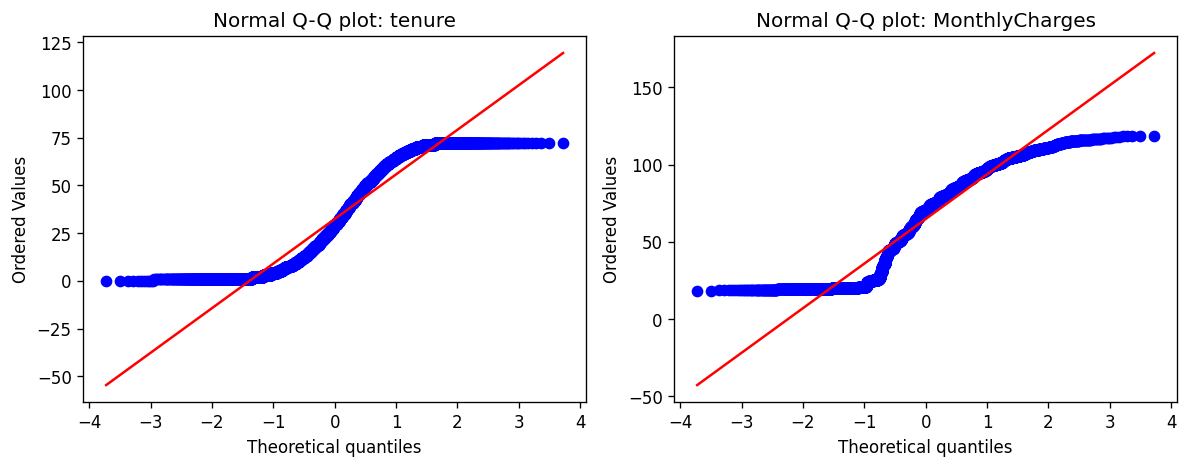

In [19]:
# Cell 19 — Normal Q–Q plots as a second check on normality
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
stats.probplot(x1, dist="norm", plot=axes[0])
axes[0].set_title("Normal Q-Q plot: tenure")
stats.probplot(x2, dist="norm", plot=axes[1])
axes[1].set_title("Normal Q-Q plot: MonthlyCharges")
plt.tight_layout()
plt.show()
print("Both Q–Q plots bend away from the straight line, especially in the tails")
print("and (for MonthlyCharges) around the two clusters. That matches the")
print("histograms and the empirical-rule counts: neither variable is normal.")


In [20]:
# Cell 20 — Why standardisation puts all variables on a common scale
print("=== Why standardisation puts all variables on a common scale ===")
print()
print("A z-score rewrites each value as how many of its own standard deviations")
print("it sits from its own mean, so every variable ends up with mean 0, SD 1")
print("and no units. Distances on tenure (months) and MonthlyCharges (dollars)")
print("can then be compared on the same scale.")
print()
print("Without that step, a variable measured in large numbers (dollars) would")
print("dominate one measured in smaller numbers (months) when distances are")
print("calculated. Standardising first prevents that. Peck and Olsen (2025)")
print("treat this as the usual reason to work with z-scores before comparing")
print("variables that were recorded in different units.")


=== Why standardisation puts all variables on a common scale ===

A z-score rewrites each value as how many of its own standard deviations
it sits from its own mean, so every variable ends up with mean 0, SD 1
and no units. Distances on tenure (months) and MonthlyCharges (dollars)
can then be compared on the same scale.

Without that step, a variable measured in large numbers (dollars) would
dominate one measured in smaller numbers (months) when distances are
calculated. Standardising first prevents that. Peck and Olsen (2025)
treat this as the usual reason to work with z-scores before comparing
variables that were recorded in different units.


---
## 7. Comparative Display: MonthlyCharges by Contract Type
---


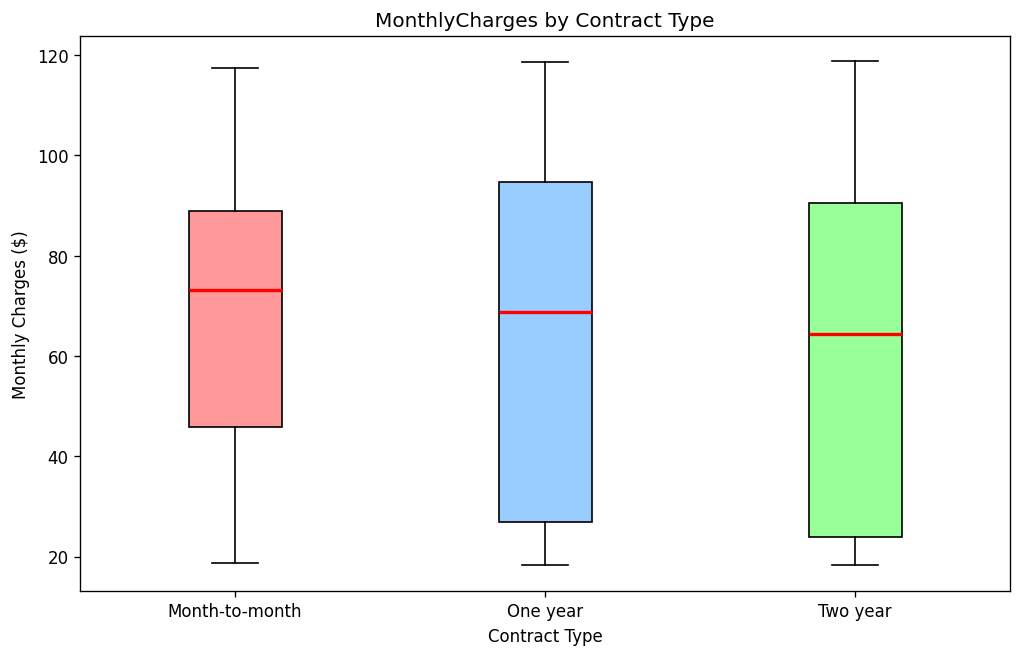

In [21]:
# Cell 21 — Side-by-side boxplots of MonthlyCharges across Contract types
order = ["Month-to-month", "One year", "Two year"]
groups = [df.loc[df["Contract"] == name, "MonthlyCharges"] for name in order]

fig, ax = plt.subplots(figsize=(10, 6))
bp = ax.boxplot(
    groups,
    tick_labels=order,
    patch_artist=True,
    medianprops=dict(color="red", linewidth=2),
)
colors = ["#FF9999", "#99CCFF", "#99FF99"]
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
ax.set_title("MonthlyCharges by Contract Type")
ax.set_xlabel("Contract Type")
ax.set_ylabel("Monthly Charges ($)")
plt.show()


In [22]:
# Cell 22 — Summary statistics by Contract type and description
print("=== MonthlyCharges by Contract Type ===")
print(f"{'Contract':<20} {'n':<8} {'Mean':<10} {'Median':<10} {'SD':<10} {'IQR':<10}")

contract_stats = {}
for name, data in zip(order, groups):
    q1 = data.quantile(0.25)
    q3 = data.quantile(0.75)
    iqr = q3 - q1
    contract_stats[name] = {
        "n": len(data),
        "mean": data.mean(),
        "median": data.median(),
        "sd": data.std(),
        "iqr": iqr,
    }
    print(
        f"{name:<20} {len(data):<8} {data.mean():<10.2f} {data.median():<10.2f} "
        f"{data.std():<10.2f} {iqr:<10.2f}"
    )

m2m = contract_stats["Month-to-month"]
y1 = contract_stats["One year"]
y2 = contract_stats["Two year"]
print()
print("Description:")
print("  The median monthly charge falls as the contract gets longer:")
print(
    f"  ${m2m['median']:.2f} for month-to-month, ${y1['median']:.2f} for one year, "
    f"${y2['median']:.2f} for two years."
)
print(
    f"  Month-to-month customers also have the narrowest spread (IQR ${m2m['iqr']:.2f}),"
)
print("  so their charges are more concentrated at the higher end, while the longer")
print(
    f"  contracts include many more low-charge customers (IQR about ${min(y1['iqr'], y2['iqr']):.0f}–${max(y1['iqr'], y2['iqr']):.0f})."
)
print("  The three boxes overlap heavily, and the means differ less than the medians,")
print("  so the contract association with charges is modest.")
print("  This is an association only — it does not show that contract type causes")
print("  the charge, since customers choose both their services and their contract.")


=== MonthlyCharges by Contract Type ===
Contract             n        Mean       Median     SD         IQR       
Month-to-month       3875     66.40      73.25      26.93      43.02     
One year             1473     65.05      68.75      31.84      67.90     
Two year             1695     60.77      64.35      34.68      66.43     

Description:
  The median monthly charge falls as the contract gets longer:
  $73.25 for month-to-month, $68.75 for one year, $64.35 for two years.
  Month-to-month customers also have the narrowest spread (IQR $43.02),
  so their charges are more concentrated at the higher end, while the longer
  contracts include many more low-charge customers (IQR about $66–$68).
  The three boxes overlap heavily, and the means differ less than the medians,
  so the contract association with charges is modest.
  This is an association only — it does not show that contract type causes
  the charge, since customers choose both their services and their contract.


---
## 8. Conclusion

Both variables are wide and only mildly skewed, in the direction the mean–median gap predicts. The 1.5 × IQR rule finds no outliers, and neither variable is approximately normal: far fewer than 68% of values lie within one standard deviation, every value lies within two, and the Q–Q plots leave the straight line. Medians and IQRs should be reported alongside means. The bimodal shape of MonthlyCharges is worth modelling later by internet-service type.

---

## References (APA 7th Edition)

BlastChar. (n.d.). *Telco customer churn* [Data set]. Kaggle. https://www.kaggle.com/datasets/blastchar/telco-customer-churn

Bruce, P., Bruce, A., & Gedeck, P. (2020). *Practical statistics for data scientists: 50+ essential concepts using R and Python* (2nd ed.). O'Reilly Media.

Peck, R., & Olsen, C. (2025). *Introduction to statistics and data analysis* (7th ed.). Cengage Learning.
